# Lab 10: Explainability with Alibi
In this lab, you'll learn about the Alibi Explain library and implement global and local explanations of tabular and image classification models.

Alibi Explain is an open source Python library aimed at machine learning model inspection and interpretation. The focus of the library is to provide high-quality implementations of black-box, white-box, local and global explanation methods for classification and regression models.

Complete all the Deliverables mentioned below and show it to a TA for credit.

## Deliverables
- Finish all the TODOs in Section 2
- Generate PD Plots. Discuss your findings about model performance with the TA and answer Q1, Q2, and Q3:
     - Q1: Which features have higher importance in the prediction? (Section 2.1)
     - Q2: What can you conclude with the PD plots? (Section 2.2)
     - Q3: Discuss with the TA the results (heatmaps). (Section 2.2)
- Show final results  about the Anchor parameters and discuss them with the TA.
- Complete the SHAP section & discuss your findings with the TA.


## Getting Started
Clone this repository and run all cells in the notebook.

### Install Dependencies

For this assignment, make sure you have the required packages installed.
```
pip install -r requirements.txt
```
(If there are any major unsolvable issues prefer running this notebook on Google Colaboratory)

### Possible Issues with installing Alibi
`TypeError: issubclass() arg 1 must be a class` \
**Solution:** https://stackoverflow.com/questions/76313592/import-langchain-error-typeerror-issubclass-arg-1-must-be-a-class
<br><br>
If there's any more issues, please contact a TA to update this list (with a solution if its solved)

In [2]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

from alibi.explainers import PartialDependence, plot_pd, plot_pd_variance
from alibi.explainers import PartialDependenceVariance


## Section 1 - Data + Modeling
In this section, we will be setting up our data, perform some preprocessing and train a model.

### 1.1 Fetching the Dataset
We are going to use the The Boston Housing Dataset in the next experiment.
https://www.cs.toronto.edu/~delve/data/boston/bostonDetail.html


There are 14 attributes in each case of the dataset:
- CRIM - per capita crime rate by town
- ZN - proportion of residential land zoned for lots over 25,000 sq.ft.
- INDUS - proportion of non-retail business acres per town.
- CHAS - Charles River dummy variable (1 if tract bounds river; 0 otherwise)
- NOX - nitric oxides concentration (parts per 10 million)
- RM - average number of rooms per dwelling
- AGE - proportion of owner-occupied units built prior to 1940
- DIS - weighted distances to five Boston employment centres
- RAD - index of accessibility to radial highways
- TAX - full-value property-tax rate per $10,000
- PTRATIO - pupil-teacher ratio by town
- B - 1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town
- LSTAT - % lower status of the population
- MEDV - Median value of owner-occupied homes in $1000's

In [3]:
df = pd.read_csv('BostonHousing.csv')
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


### 1.2 Dataset Preprocessing

Run the following code necessary to pre-process the data for alibi.

In [4]:
# extract feature names
feature_names = df.columns.tolist()
target_feature = 'medv'
feature_names.remove(target_feature)

# define target names
target_names = [target_feature]

#  define categorical columns
categorical_columns_names = []

# define categorical and numerical indices for later preprocessing
categorical_columns_indices = [feature_names.index(cn) for cn in categorical_columns_names]
numerical_columns_indices = [feature_names.index(fn) for fn in feature_names if fn not in categorical_columns_names]

# extract data
X = df[feature_names]
# define target column
y = df[target_feature]

# split data in train & test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [5]:
# define and fit the original encoder
oe = OrdinalEncoder().fit(X_train[categorical_columns_names])

# transform the categorical columns to ordinal encoding
X_train.loc[:, categorical_columns_names] = oe.transform(X_train[categorical_columns_names])
X_test.loc[:, categorical_columns_names] = oe.transform(X_test[categorical_columns_names])

# convert data to numpy
X_train, y_train = X_train.to_numpy(), y_train.to_numpy()
X_test, y_test = X_test.to_numpy(), y_test.to_numpy()

# define categorical mappings
categorical_names = {i: list(v) for (i, v) in zip(categorical_columns_indices, oe.categories_)}

In [6]:
# define numerical standard sclaer
num_transf = StandardScaler()

# define categorical one-hot encoder
cat_transf = OneHotEncoder(
    categories=[range(len(x)) for x in categorical_names.values()],
    handle_unknown='ignore',
)

# define preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', cat_transf, categorical_columns_indices),
        ('num', num_transf, numerical_columns_indices),
    ],
    sparse_threshold=0
)


In [7]:
# fit preprocessor
preprocessor.fit(X_train)

# preprocess train and test datasets
X_train_ohe = preprocessor.transform(X_train)
X_test_ohe = preprocessor.transform(X_test)

### 1.3 Training the Model
Run the cell to fit the model to the dataset

In [8]:
# define and fit regressor - feel free to play with the hyperparameters
predictor = RandomForestRegressor(random_state=0)
predictor.fit(X_train_ohe, y_train)

# compute scores
print('Train score: %.2f' % (predictor.score(X_train_ohe, y_train)))
print('Test score: %.2f' % (predictor.score(X_test_ohe, y_test)))

Train score: 0.98
Test score: 0.77


## Section 2 - Explainability with Alibi
In this section, we will be finally using Alibi to explain our trained model using different techniques. Fill in the TODOs and generate plots where required.

In [9]:
# Creating a Prediction Function - Includes pipeline from preprocessing to prediction
prediction_fn = lambda x: predictor.predict(preprocessor.transform(x))

#### Computing Explanations
We will finally be computing explanations for selected features. Play around with different methods.

### 2.1 Partial Dependence Variance (PDV)  - Feature Importance

Partial Dependence Variance is a method to compute the global feature importance or the feature interaction of a pair of features.

Complete the code below and answer Q1

**Q1: Which features have higher importance in the prediction?**

array([[<Axes: title={'center': 'imp(rm) = 6.057'}, xlabel='rm', ylabel='medv'>,
        <Axes: title={'center': 'imp(lstat) = 4.159'}, xlabel='lstat', ylabel='medv'>,
        <Axes: title={'center': 'imp(dis) = 0.589'}, xlabel='dis', ylabel='medv'>],
       [<Axes: title={'center': 'imp(ptratio) = 0.533'}, xlabel='ptratio', ylabel='medv'>,
        <Axes: title={'center': 'imp(tax) = 0.509'}, xlabel='tax', ylabel='medv'>,
        <Axes: title={'center': 'imp(nox) = 0.424'}, xlabel='nox', ylabel='medv'>],
       [<Axes: title={'center': 'imp(crim) = 0.311'}, xlabel='crim', ylabel='medv'>,
        <Axes: title={'center': 'imp(indus) = 0.267'}, xlabel='indus', ylabel='medv'>,
        <Axes: title={'center': 'imp(age) = 0.263'}, xlabel='age', ylabel='medv'>],
       [<Axes: title={'center': 'imp(b) = 0.211'}, xlabel='b', ylabel='medv'>,
        <Axes: title={'center': 'imp(chas) = 0.047'}, xlabel='chas', ylabel='medv'>,
        <Axes: title={'center': 'imp(rad) = 0.042'}, xlabel='rad', yla

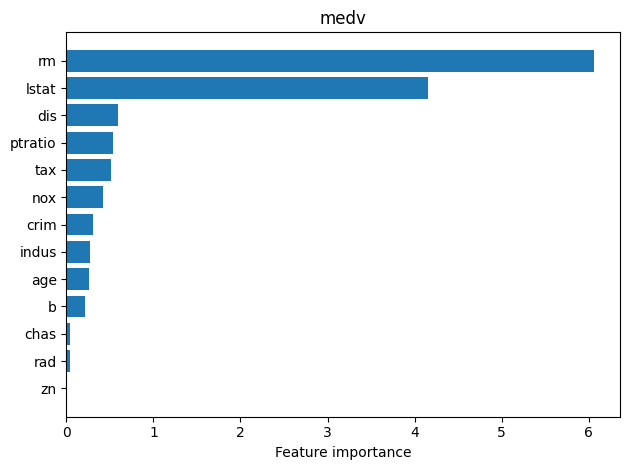

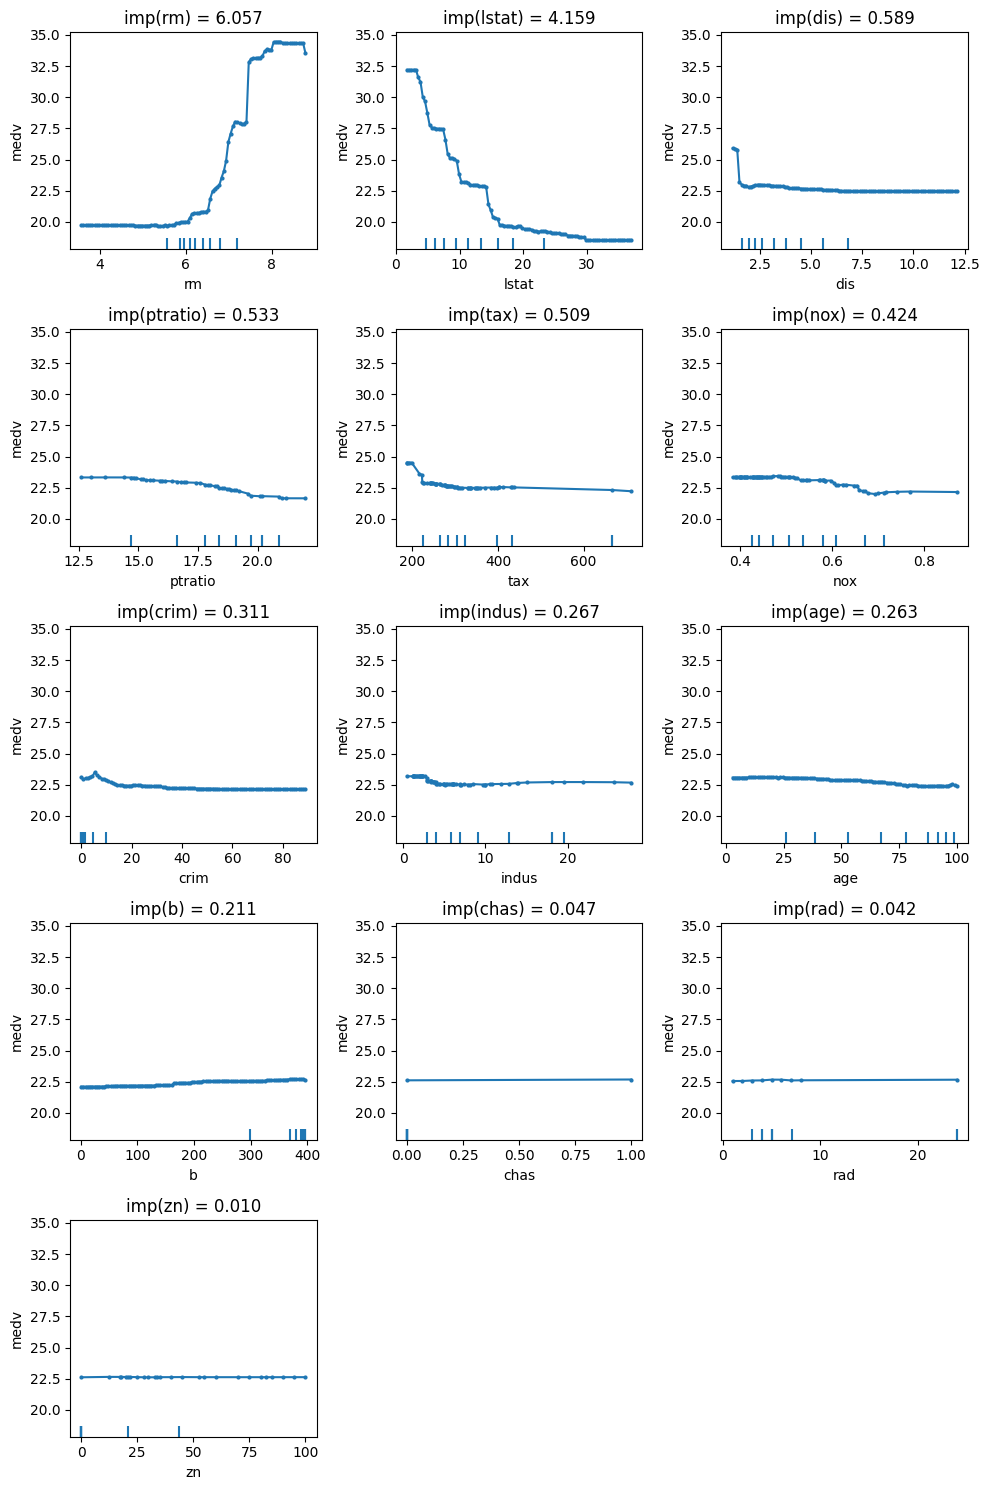

In [11]:
explainer = PartialDependenceVariance(
    predictor=prediction_fn,
    feature_names=feature_names,
    categorical_names=categorical_names,
    target_names=target_names,
)

exp_importance = explainer.explain(X=X_train, method='importance')

plot_pd_variance(exp=exp_importance)
plot_pd_variance(
    exp=exp_importance,
    summarise=False,
    fig_kw={'figheight': 15, 'figwidth': 10},
)

### 2.2 Partial Dependence (PD)

Partial Dependence is a method to visualize the marginal effect that one or two features have on the predicted outcome of a machine learning model.

By inspecting the PD plots, one can understand whether the relation between a feature/pair of features is, for example, a simple linear or quadratic relation, whether it presents a monotonically increasing or decreasing trend, or reveal a more complex response.

#### Computing Explanations
We will finally be computing explanations. You can try different modes of `kind` to see different visualizations. (Suggestion: use `both` to visualize all data)

As per the documentation,
> `kind` - If set to `average`, then only the partial dependence (PD) averaged across all samples from the dataset is returned. If set to `individual`, then only the individual conditional expectation (ICE) is returned for each individual from the dataset. Otherwise, if set to `both`, then both the PD and the ICE are returned.


Run the following code with all features and also selecting some specific features.

**Q2: What can you conclude?**

In [12]:
# Define explainer
explainer_pd = PartialDependence(predictor=prediction_fn,
                       feature_names=feature_names,
                       categorical_names=categorical_names,
                       target_names=target_names)


In [13]:
feature_names

['crim',
 'zn',
 'indus',
 'chas',
 'nox',
 'rm',
 'age',
 'dis',
 'rad',
 'tax',
 'ptratio',
 'b',
 'lstat']

In [14]:
# you can also compute explanations for selected features.
features = [
    feature_names.index("lstat"),
    feature_names.index("rm"),
    feature_names.index("dis"),
    feature_names.index("nox"),
    feature_names.index("ptratio"),
]


array([[<Axes: xlabel='lstat', ylabel='medv'>,
        <Axes: xlabel='rm', ylabel='medv'>,
        <Axes: xlabel='dis', ylabel='medv'>],
       [<Axes: xlabel='nox', ylabel='medv'>,
        <Axes: xlabel='ptratio', ylabel='medv'>, None]], dtype=object)

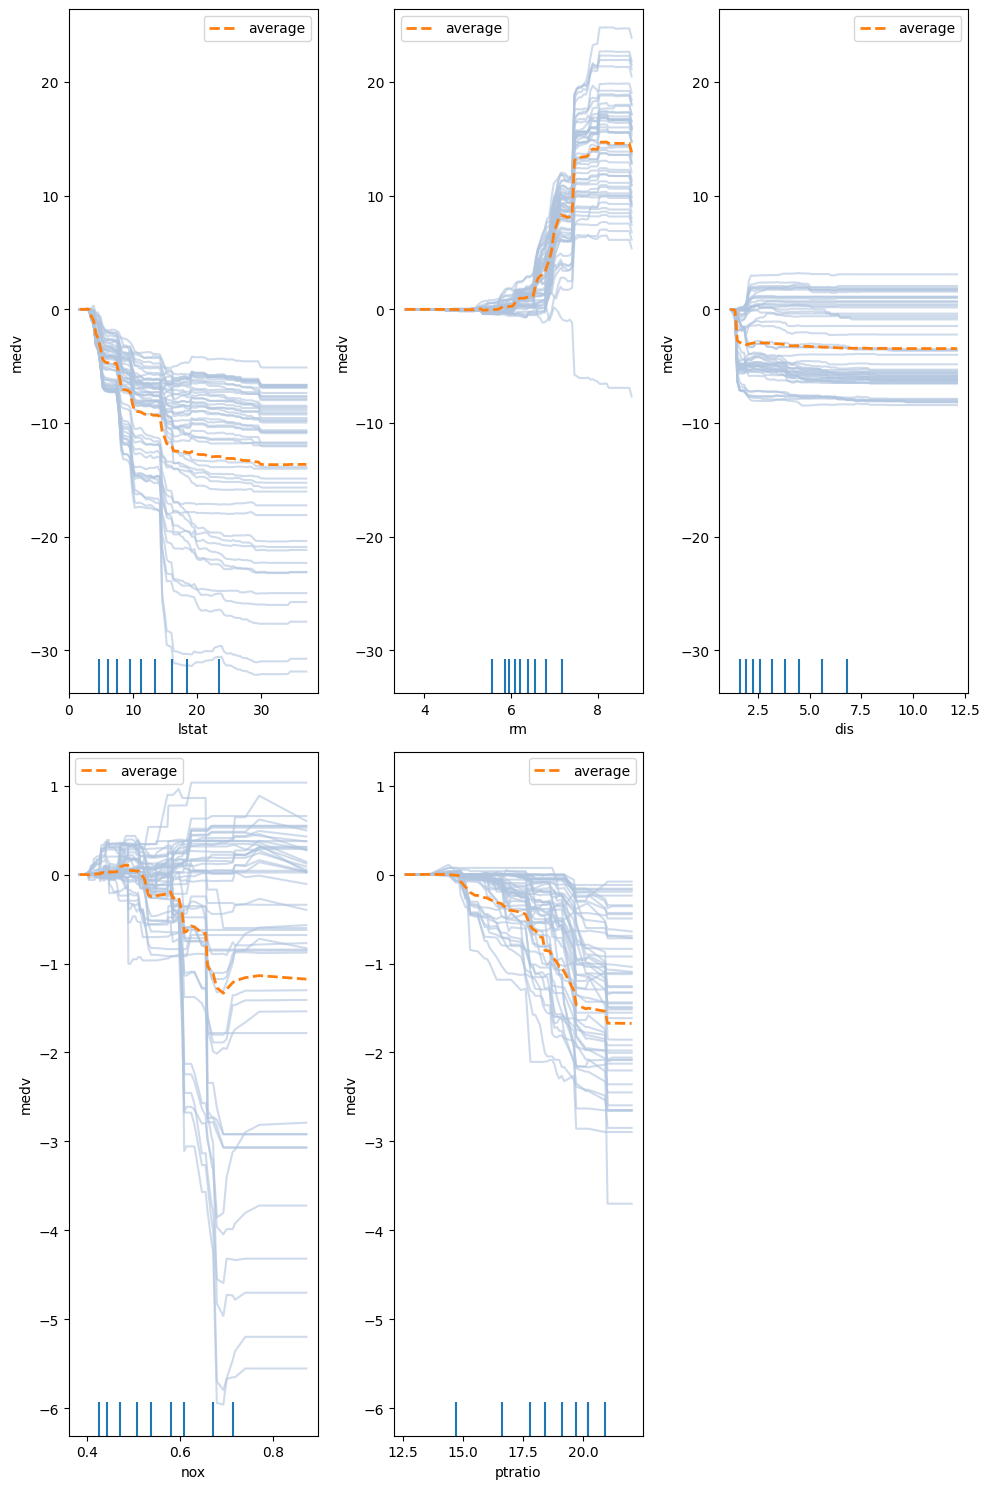

In [15]:
# compute explainer
exp = explainer_pd.explain(
    X=X_train,
    features=features,
    kind='both',
)
# Plot partial dependence curve
plot_pd(
    exp=exp,
    n_cols=3,
    n_ice=50,
    sharey='row',
    center=True,
    fig_kw={'figheight': 15, 'figwidth': 10},
)


### Check Partial Dependence for Two Features
Choose pairs of features to visualize their relationships and interactions with each other. These plots may be a bit confusing so try your best to explain whatever you understand to the TA.
We suggest to select a feature with high  and low importance. 
You can also try different combinations of features in order to get better conclusion.

**Q3: Discuss with the TA the results.**

In [ ]:
# select feature combination
FEATURE1 = 'lstat'
FEATURE2 = 'rm'

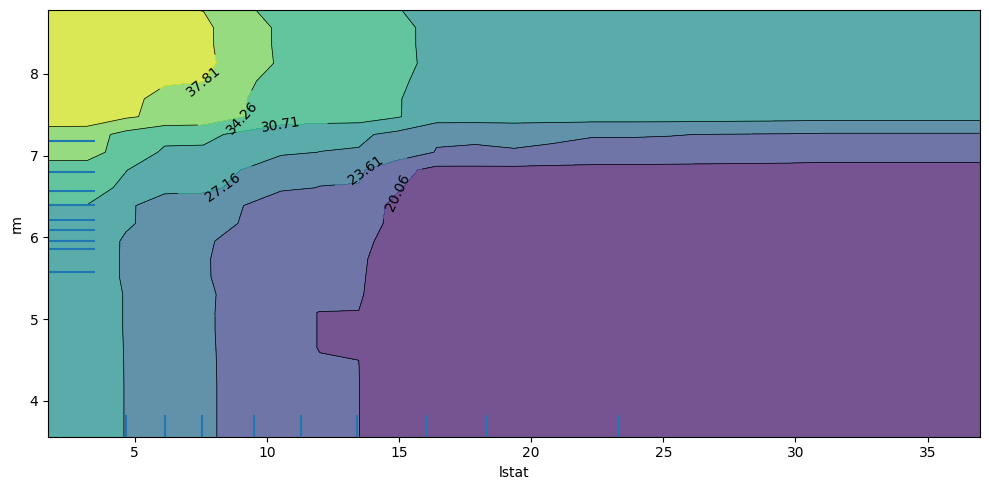

In [17]:
combined_features = [(feature_names.index(FEATURE1), feature_names.index(FEATURE2))]

# compute explanations
comb_exp = explainer_pd.explain(X=X_train,
                        features=combined_features,
                        kind='average',
                        grid_resolution=25) # kind = [both, individual, average]

# plot partial dependece curves
plot_pd(exp=comb_exp,
        n_cols=3,
        n_ice=50,
        sharey='row',
        center = True,
        fig_kw={'figheight': 5, 'figwidth': 10});


X-Axis (Feature 0): lstat. This represents the percentage of the lower-status population in the neighborhood. The values range from roughly 0% to 35%.

Y-Axis (Feature 1): rm. This represents the average number of rooms per dwelling. The values range from about 4 to 8.5 rooms.

Color Scale / Contour Lines: The colors represent the model's predicted output (which is medv, the median home value).

Bright Yellow = Highest predicted home value.

Dark Purple/Blue = Lowest predicted home value

The "Premium" Zone (Top Left): Look at the bright yellow area. Houses that have a high number of rooms (rm > 7.5) AND are located in neighborhoods with very few lower-status residents (lstat < 5%) have the absolute highest predicted values.

The "Discount" Zone (Bottom Right): Look at the dark purple area. Houses that are small (low rm, < 5.5) AND are located in neighborhoods with a high percentage of lower-status residents (lstat > 20%) have the lowest predicted values.

The Interaction Effect: This is the coolest part of the plot. Notice how the contour lines slope.

If you have a massive house with 8 rooms (top of the Y-axis), its predicted value is extremely high only if the lstat is low. If you move to the right along the top of the graph (increasing the lstat), the color quickly drops from yellow to green to blue. This means the neighborhood's status (lstat) heavily restricts the value of a large house (rm).

Conversely, if you are in a neighborhood with a very low lstat (far left of the X-axis), even a smaller house with only 5 or 6 rooms retains a decent amount of value (teal/green color) compared to that same small house in a high lstat area.

## 2.3 Anchors
This algorithm provides model-agnostic (black box) and human interpretable explanations suitable for classification models applied to images, text and tabular data. The idea behind anchors is to explain the behaviour of complex models with high-precision rules called anchors. These anchors are locally sufficient conditions to ensure a certain prediction with a high degree of confidence. Run all the cells and try different parameters to see how this algorithm works.

We will be explaining predictions from the ImageNet model on the cats dataset.

In [27]:
import tensorflow as tf
import matplotlib

import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input, decode_predictions
from tensorflow.keras.preprocessing import image
from alibi.datasets import load_cats
from alibi.explainers import AnchorImage

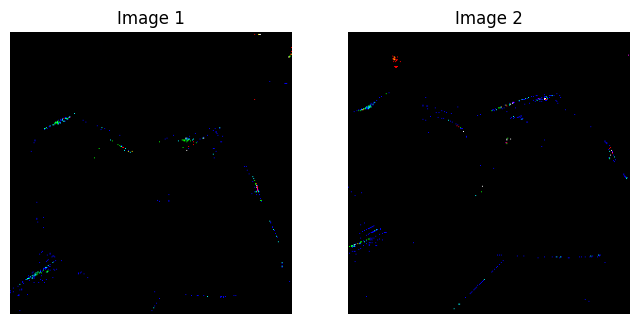

In [30]:
# Path to your image

# You are free to play around with other images. 
# Here are two pictures of Professor Bogdan's beautiful cat.
img1_path = "hyPURRmeter_fineMEOWing.jpg"
img2_path = "your_TA.jpg"

def load_and_preprocess(img_path):
    img = image.load_img(img_path, target_size=(299, 299))
    img_array = image.img_to_array(img)
    img_preprocessed = preprocess_input(np.expand_dims(img_array, axis=0))
    return img_array, img_preprocessed

# Load and preprocess
img1 = image.load_img(img1_path, target_size=(299, 299))
img1_array = image.img_to_array(img1)
img1_preprocessed = preprocess_input(np.expand_dims(img1_array, axis=0))

img2 = image.load_img(img2_path, target_size=(299, 299))
img2_array = image.img_to_array(img2)
img2_preprocessed = preprocess_input(np.expand_dims(img2_array, axis=0))

# Display both images
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(img1_array.astype('uint8'))
plt.title("Image 1")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img2_array.astype('uint8'))
plt.title("Image 2")
plt.axis('off')
plt.show()


In [31]:
#load pre-trained model
model = InceptionV3(weights='imagenet')
predict_fn = lambda x: model.predict(x)

96112376/96112376 [==============================] - 15s 0us/step


In [32]:
#check model predictions for both images.
for idx, (arr, prep) in enumerate([(img1_array, img1_preprocessed), (img2_array, img2_preprocessed)], start=1):
    preds = model.predict(prep)
    decoded = decode_predictions(preds, top=3)[0]
    print(f"\nTop predictions for Image {idx}:")
    for _, label, prob in decoded:
        print(f"  {label:20s}: {prob:.3f}")

35363/35363 [==============================] - 0s 1us/step

Top predictions for Image 1:
  Persian_cat         : 0.502
  Siamese_cat         : 0.139
  carton              : 0.055
1/1 [==============================] - 0s 66ms/step

Top predictions for Image 2:
  Persian_cat         : 0.574
  Siamese_cat         : 0.157
  crate               : 0.008


In [33]:
#create and run anchorImage explainer
image_shape = (299, 299, 3)
segmentation_fn = 'slic'  # Superpixel segmentation
kwargs = {'n_segments': 15, 'compactness': 20, 'sigma': .5, 'start_label': 0}


In [34]:
explainer = AnchorImage(
    predict_fn,
    image_shape=image_shape,
    segmentation_fn=segmentation_fn,
    segmentation_kwargs=kwargs,
    images_background=None
)


1/1 [==============================] - 0s 58ms/step


In [35]:
#choose an image to explain

image_to_explain = img1_preprocessed[0]  # or img2_preprocessed[0]
np.random.seed(0)

explanation = explainer.explain(image_to_explain, threshold=.95, p_sample=.5, tau=0.25)


4/4 [==============================] - 2s 470ms/step


(-0.5, 298.5, 298.5, -0.5)

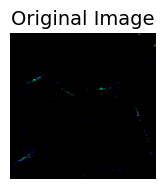

In [36]:
plt.subplot(1, 3, 1)
plt.imshow(img1_array.astype('uint8'))
plt.title("Original Image", fontsize=14)
plt.axis('off')


(-0.5, 298.5, 298.5, -0.5)

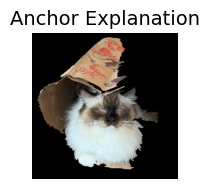

In [37]:
plt.subplot(1, 3, 2)
plt.imshow(explanation.anchor)
plt.title("Anchor Explanation", fontsize=14)
plt.axis('off')

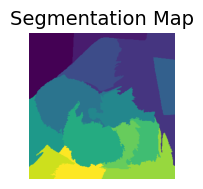

In [38]:
plt.subplot(1, 3, 3)
plt.imshow(explanation.segments)
plt.title("Segmentation Map", fontsize=14)
plt.axis('off')
plt.show()

Questions:
1. What part of your image did the Anchor explainer focus on?

It focused on the cat and the bag. 

2. Does the highlighted region make sense when you compare it to the model's predicted label?

It does because the higher percentages were types of cats and the lower percentage was related to a carton, which was referencing the bag. 

3. What does it mean if the highlighted region seems unrelated to the object?

For one, it could mean the model is using the background texture. Furthermore, the object might be too small or off-center. 

## 3 SHAP
SHAP is a unified framework for interpreting predictions based on Shapley values from cooperative game theory.
It attributes the prediction of a model to each input feature by quantifying how much that feature contributed to increasing or decreasing the final prediction compared to the model’s average output.
In other words, SHAP tells us:
“If I remove or change this feature, how would the model’s prediction change?”
SHAP values are additive, meaning that for each prediction, the sum of all feature contributions equals the model’s output minus the baseline (average) prediction.
This makes SHAP both mathematically grounded and visually interpretable.
In this section, you will:
1. Generate global feature importance using SHAP summary plots.
2. Analyze local explanations for a specific instance using waterfall plots.
3. Compare SHAP’s results with your earlier Partial Dependence and Anchor explanations to see whether they agree.

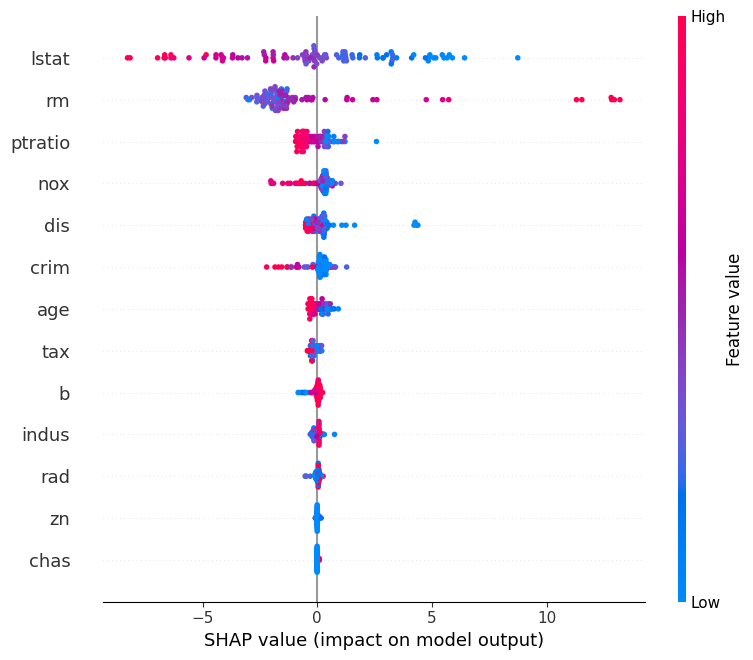

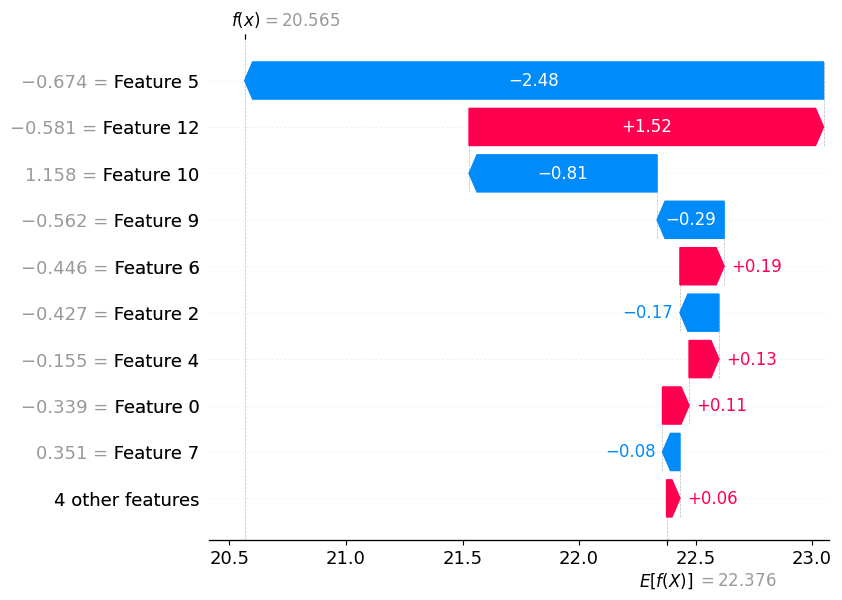

In [39]:
import shap
import matplotlib.pyplot as plt

# Define SHAP explainer for the Random Forest regressor
shap_explainer = shap.Explainer(predictor, X_train_ohe)

# Compute SHAP values
shap_values = shap_explainer(X_test_ohe)

# Global feature importance
shap.summary_plot(shap_values, X_test, feature_names=feature_names)
# plt.title("Global SHAP Feature Importance")
# plt.show()

# Local explanation for one instance
idx = 5
shap.plots.waterfall(shap_values[idx])


Plots:
1. SHAP summary / beeswarm plot
   - one house per sample data point
   - ordered by importance with top being more influential on the feature value (more red)
   - X-axis: positive right pushes prediction up, negative left pushes prediction down
   - If red dots are mostly on the right, high values of that feature increase prediction.
   - If red dots are mostly on the left, high values decrease prediction.
   - Wide horizontal spread = strong/variable effect.
2. SHAP bar (mean absolute SHAP) plot
   - Shows mean absolute impact per feature
   - Longer bar = feature has larger overall influence on predictions.
   - Gives magnitude only not direction
   - It tells you what matters most
   - Not whether high values increase or decrease

## 4 Reflection & comparison
You have now explored three complementary ways to understand your model’s behavior:
Partial Dependence (PD): shows average feature effects (global trend).
Anchors: provides human-readable rules explaining specific predictions (local).
SHAP: quantifies feature contributions for each prediction (both global and local).
Each method offers a different lens:
1. PD plots summarize what the model learns overall,
2. Anchors explain why a single decision was made, and
3. SHAP connects both by showing how much each feature contributed numerically.
Use this final section to connect the dots between them.

Questions to answer:

1. Do any of the top features raise ethical or fairness concerns?
Could the model be relying on socioeconomic or location-based variables in ways that might bias predictions?

lstat referring to lower-status population could already indicate that as an issue being used as a proxy when it could refer to historical inequities in socioeconomic status and neighborhood segregation. These values can bias future predictions which we wouldn't want in our model even if it is predictable to not continue that trend. 

2. Do SHAP’s most important features agree with those found by PD plots or Anchor explanations?
If they differ, why might that happen?

They should usually agree with rm, lstat (features that matter the most), but they may differ in ranking and effect size because SHAP is a more individual feature and individual point related plot while PD is a global marginal effect plot that averages over the data distribution. PD will likely blur the heterogeneous effects compared to SHAP because SHAP captures the per sample effects. Furthermore, anchor explanations are local and rule-based (here with images), so they aren't directly comparable as a global feature-importance metric for the tabular housing model,but likely are more similar to the SHAP in most cases. 


3. Write a short paragraph (3 sentences max) summarizing what your model relies on and how confident you are in its interpretability.

The model relies on a small set of structural and neighborhood-related features. rm and lstat are the greatest features of average number of rooms per dwelling and lower status population % respectively. This is consistent across the general feature importance and then SHAP and PD analyses. On the SHAP, they also have the most variable spread relating to their variable effect. For the PD plot, we can see the general interaction between lstat and rm showcasing that with high of each and high of the other that is the lowest and highest predicted value but they are greatly affected as one lowers even if the other remains high in predicted value. 

### References
1. https://docs.seldon.io/projects/alibi/en/stable/examples/pdp_regression_bike.html
2. https://docs.seldon.io/projects/alibi/en/stable/methods/PartialDependence.html
3. https://docs.seldon.io/projects/alibi/en/stable/examples/anchor_image_imagenet.html
